In [1]:
#Tahapan Menelaah data b
# Tahap 1: Mengumpulkan Data
# ======================================================

# Mengimport libraries yang diperlukan
#import librery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt #visualisasi grafik
import seaborn as sns #visualisasi data

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Dataset_Student Mental Health & Resilience Dataset/mental_health_dataset.csv')

print(df.head(5))

   Student_ID  Age  Gender   GPA  Stress_Level  Anxiety_Score  \
0           1   23   Other  2.52             5             20   
1           2   19    Male  2.74             5              3   
2           3   21  Female  3.53             5             11   
3           4   18    Male  2.04             4             15   
4           5   19   Other  2.87             1              2   

   Depression_Score                                  Daily_Reflections  \
0                 6  Onto foreign do environmental anyone every nea...   
1                 7  Party but others visit admit industry country ...   
2                24  Religious sure wait do chance decade according...   
3                14            A task effect entire coach join series.   
4                 4  Knowledge several camera wait week write quali...   

   Sleep_Hours  Steps_Per_Day Mood_Description  Sentiment_Score  \
0          6.8           4166            Happy           0.0000   
1          5.1           4949 

In [3]:
#Melihat jumlah kolom dan baris data
df.shape

(500, 13)

In [4]:
#Melihat Judul Kolom
df.columns

Index(['Student_ID', 'Age', 'Gender', 'GPA', 'Stress_Level', 'Anxiety_Score',
       'Depression_Score', 'Daily_Reflections', 'Sleep_Hours', 'Steps_Per_Day',
       'Mood_Description', 'Sentiment_Score', 'Mental_Health_Status'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            500 non-null    int64  
 1   Age                   500 non-null    int64  
 2   Gender                500 non-null    object 
 3   GPA                   500 non-null    float64
 4   Stress_Level          500 non-null    int64  
 5   Anxiety_Score         500 non-null    int64  
 6   Depression_Score      500 non-null    int64  
 7   Daily_Reflections     500 non-null    object 
 8   Sleep_Hours           500 non-null    float64
 9   Steps_Per_Day         500 non-null    int64  
 10  Mood_Description      500 non-null    object 
 11  Sentiment_Score       500 non-null    float64
 12  Mental_Health_Status  500 non-null    int64  
dtypes: float64(3), int64(7), object(3)
memory usage: 50.9+ KB


In [6]:
#Mengecek tipe data yang Hilang
df.dtypes

,0
Student_ID,int64
Age,int64
Gender,object
GPA,float64
Stress_Level,int64
Anxiety_Score,int64
Depression_Score,int64
Daily_Reflections,object
Sleep_Hours,float64
Steps_Per_Day,int64


In [7]:
df.describe()


,Student_ID,Age,GPA,Stress_Level,Anxiety_Score,Depression_Score,Sleep_Hours,Steps_Per_Day,Sentiment_Score,Mental_Health_Status
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,250.500000,20.366000,2.810940,3.062000,9.812000,13.618000,6.06440,6067.008000,0.186588,1.638000
std,144.481833,2.272967,0.513825,1.431872,6.345486,8.316153,1.52404,1974.215196,0.367707,0.565328
min,1.000000,17.000000,1.290000,1.000000,0.000000,0.000000,3.00000,2000.000000,-0.859100,0.000000
25%,125.750000,18.000000,2.460000,2.000000,4.000000,6.000000,5.00000,4700.250000,0.000000,1.000000
50%,250.500000,20.000000,2.790000,3.000000,10.000000,14.000000,6.15000,6019.000000,0.190100,2.000000
75%,375.250000,22.000000,3.190000,4.000000,15.000000,21.000000,7.10000,7447.750000,0.493900,2.000000
max,500.000000,24.000000,4.000000,5.000000,21.000000,27.000000,9.00000,12000.000000,0.921700,2.000000


In [8]:
#melihat data mising value / data kosong
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
GPA,0
Stress_Level,0
Anxiety_Score,0
Depression_Score,0
Daily_Reflections,0
Sleep_Hours,0
Steps_Per_Day,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
#cek reng numerik yang ti daka masuk akal
rules = {
    'GPA': (0, 4),
    'Stress_Level': (0, 10),
    'Anxiety_Score': (0, 10),
    'Depression_Score': (0, 10)
}

for col, (min_val, max_val) in rules.items():
    invalid = df[(df[col] < min_val) | (df[col] > max_val)]
    print(f"{col}: {len(invalid)} data tidak valid")

GPA: 0 data tidak valid
Stress_Level: 0 data tidak valid
Anxiety_Score: 232 data tidak valid
Depression_Score: 301 data tidak valid


In [11]:
from sklearn.preprocessing import MinMaxScaler

# Kolom yang akan dinormalisasi
cols = [
    'GPA',
    'Stress_Level',
    'Anxiety_Score',
    'Depression_Score'
]

# Membuat objek scaler
scaler = MinMaxScaler()

# Normalisasi
df[cols] = scaler.fit_transform(df[cols])

# Melihat hasil 5 baris pertama
print(df[cols].head())

        GPA  Stress_Level  Anxiety_Score  Depression_Score
0  0.453875          1.00       0.952381          0.222222
1  0.535055          1.00       0.142857          0.259259
2  0.826568          1.00       0.523810          0.888889
3  0.276753          0.75       0.714286          0.518519
4  0.583026          0.00       0.095238          0.148148


In [13]:
#cek reng numerik yang tidaka masuk akal setelah di pangil
rules = {
    'GPA': (0, 4),
    'Stress_Level': (0, 10),
    'Anxiety_Score': (0, 10),
    'Depression_Score': (0, 10)
}

for col, (min_val, max_val) in rules.items():
    invalid = df[(df[col] < min_val) | (df[col] > max_val)]
    print(f"{col}: {len(invalid)} data tidak valid")

GPA: 0 data tidak valid
Stress_Level: 0 data tidak valid
Anxiety_Score: 0 data tidak valid
Depression_Score: 0 data tidak valid


In [47]:
# The 'Student_ID' column has already been dropped in a previous cell.

In [48]:
print(df.head(5))

        GPA  Stress_Level  Anxiety_Score  Depression_Score  Daily_Reflections  \
0  0.453875          1.00       0.952381          0.222222                280   
1  0.535055          1.00       0.142857          0.259259                293   
2  0.826568          1.00       0.523810          0.888889                328   
3  0.276753          0.75       0.714286          0.518519                  0   
4  0.583026          0.00       0.095238          0.148148                206   

   Mood_Description  Mental_Health_Status  
0                 1                     2  
1                 6                     2  
2                 4                     2  
3                 4                     2  
4                 1                     0  


In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

df['Mood_Description'] = le.fit_transform(df['Mood_Description'])

In [16]:
le_reflection = LabelEncoder()

df['Daily_Reflections'] = le_reflection.fit_transform(
    df['Daily_Reflections']
)

In [49]:
print(df.head(5))

        GPA  Stress_Level  Anxiety_Score  Depression_Score  Daily_Reflections  \
0  0.453875          1.00       0.952381          0.222222                280   
1  0.535055          1.00       0.142857          0.259259                293   
2  0.826568          1.00       0.523810          0.888889                328   
3  0.276753          0.75       0.714286          0.518519                  0   
4  0.583026          0.00       0.095238          0.148148                206   

   Mood_Description  Mental_Health_Status  
0                 1                     2  
1                 6                     2  
2                 4                     2  
3                 4                     2  
4                 1                     0  


In [18]:
cols = ["Mood_Description"]
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

In [20]:
df.dtypes

,0
Student_ID,int64
Age,int64
Gender,int64
GPA,float64
Stress_Level,float64
Anxiety_Score,float64
Depression_Score,float64
Daily_Reflections,int64
Sleep_Hours,float64
Steps_Per_Day,int64


In [21]:
#isualisasi Data
import warnings

In [22]:
warnings.filterwarnings('ignore')

In [23]:
#sns.countplot(data=df)

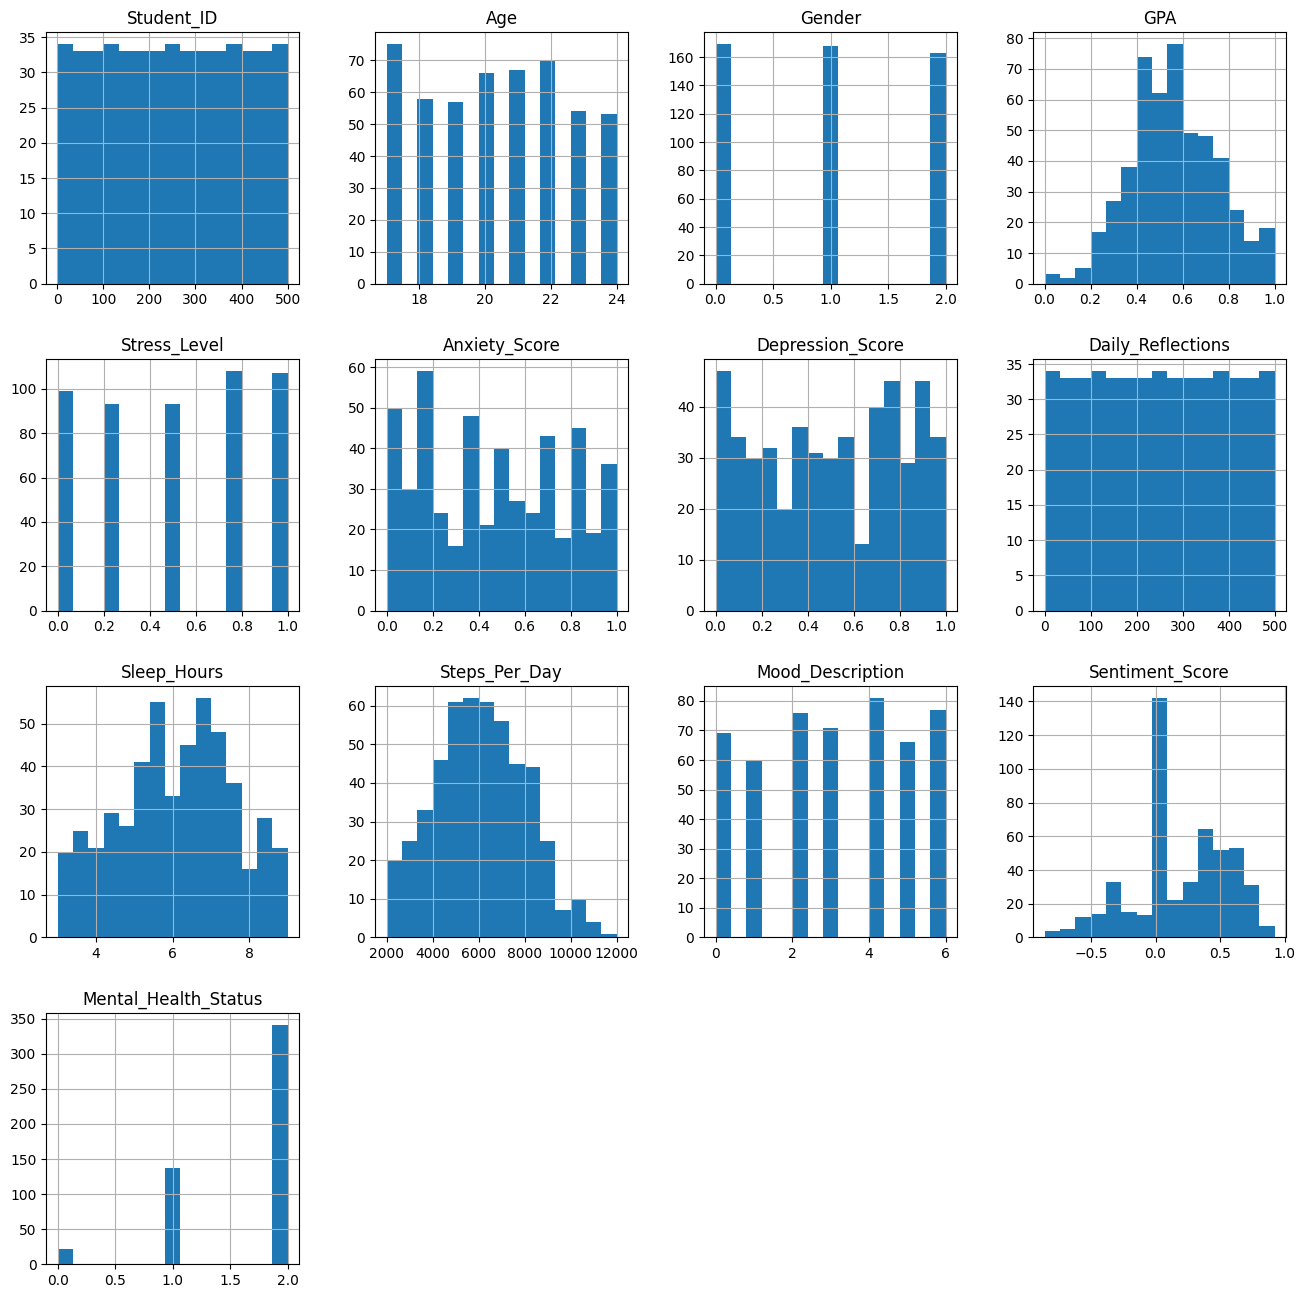

In [27]:
df.hist(bins=15,figsize=(16,16))
plt.show()

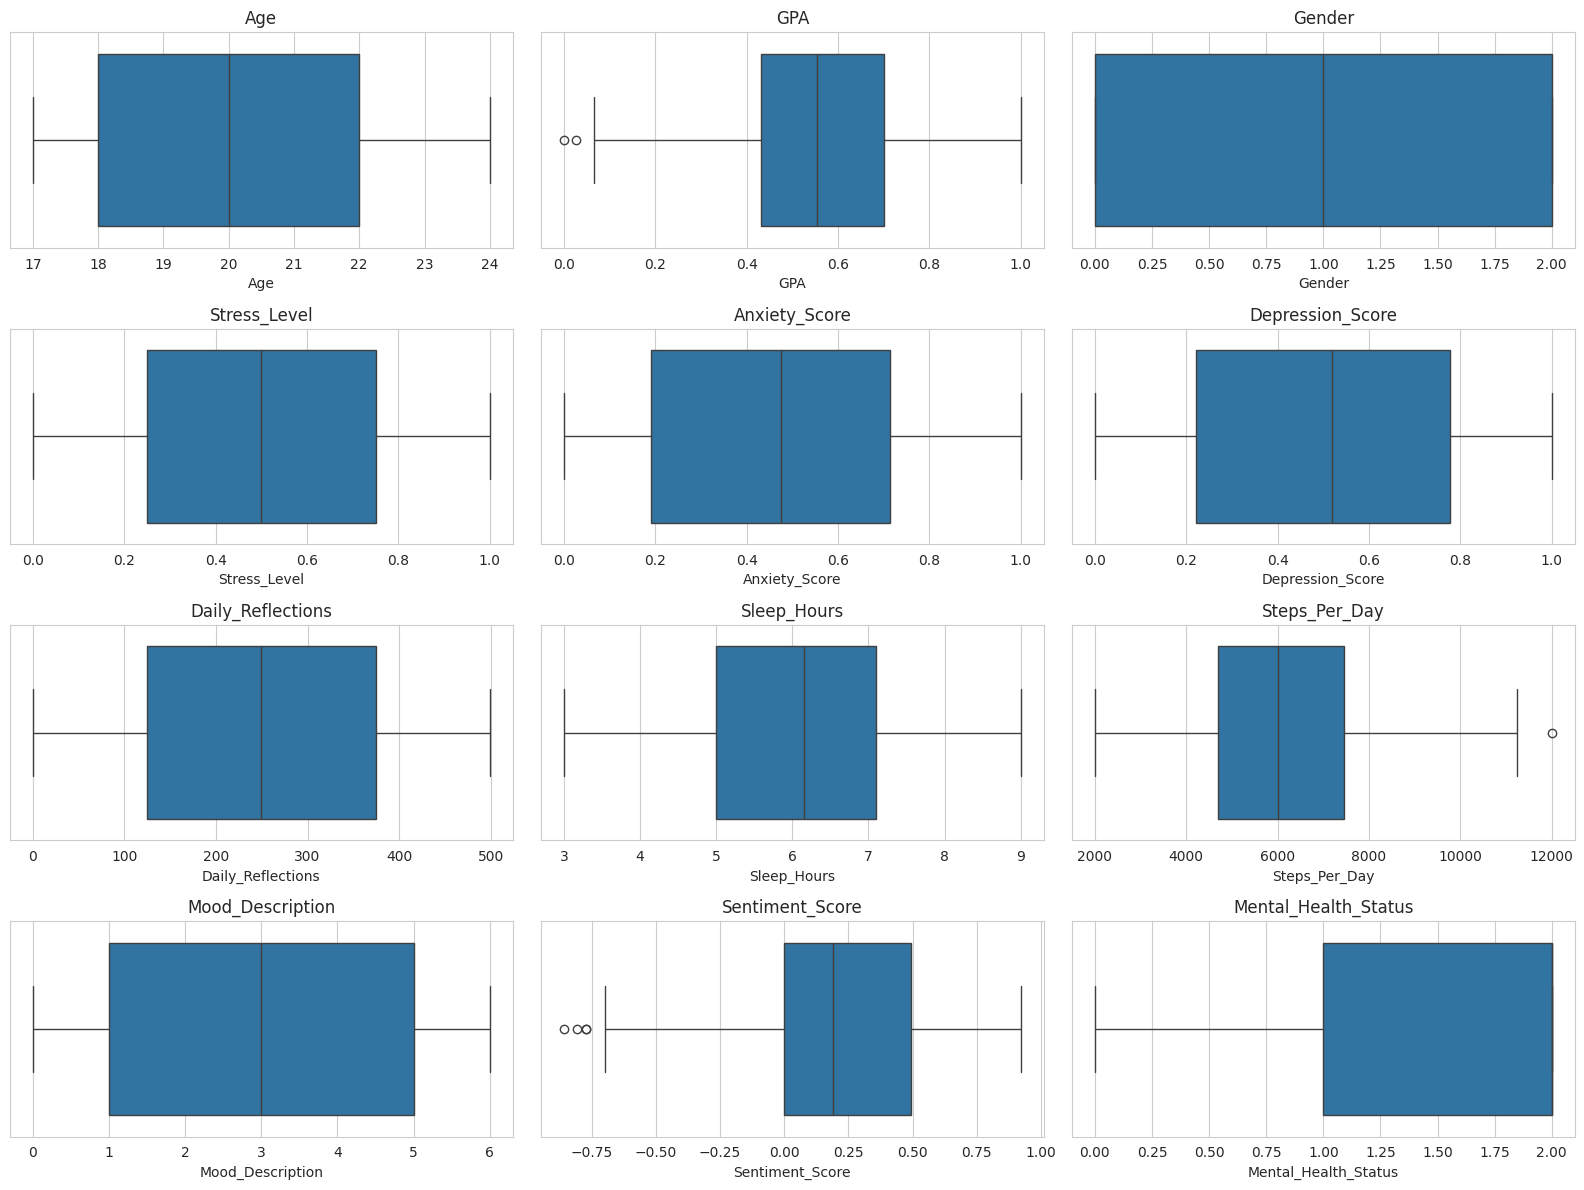

In [28]:
#Box Plot
plt.figure(figsize=(16,12))
sns.set_style(style='whitegrid')

# List of numerical columns that are not entirely NaN and suitable for box plots
numerical_columns_to_plot = [
    'Age', 'GPA', 'Gender', 'Stress_Level', 'Anxiety_Score',
    'Depression_Score','Daily_Reflections', 'Sleep_Hours', 'Steps_Per_Day', 'Mood_Description', 'Sentiment_Score',
    'Mental_Health_Status'
]

# Adjust subplot layout for 10 plots (e.g., 4 rows, 3 columns)
num_rows = 4
num_cols = 3

for i, col in enumerate(numerical_columns_to_plot):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(x=col, data=df)
    plt.title(col) # Add title for clarity

plt.tight_layout() # Adjust layout to prevent overlapping titles
plt.show()

In [29]:
# Membuat salinan dataset
df_clean = df.copy()

# Kolom yang akan dibersihkan dari outlier
columns = ['Sentiment_Score', 'GPA', 'Steps_Per_Day']

for col in columns:
    # Menghitung Q1, Q3, dan IQR
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    # Menentukan batas bawah dan batas atas
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Menghapus outlier
    df_clean = df_clean[
        (df_clean[col] >= lower_bound) &
        (df_clean[col] <= upper_bound)
    ]

# Menampilkan jumlah data sebelum dan sesudah
print("Jumlah data sebelum:", len(df))
print("Jumlah data sesudah:", len(df_clean))
print("Jumlah data yang dihapus:", len(df) - len(df_clean))

Jumlah data sebelum: 500
Jumlah data sesudah: 493
Jumlah data yang dihapus: 7


In [30]:
columns = ['Sentiment_Score', 'GPA', 'Steps_Per_Day']

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"{col}: {len(outliers)} outlier")

Sentiment_Score: 4 outlier
GPA: 2 outlier
Steps_Per_Day: 1 outlier


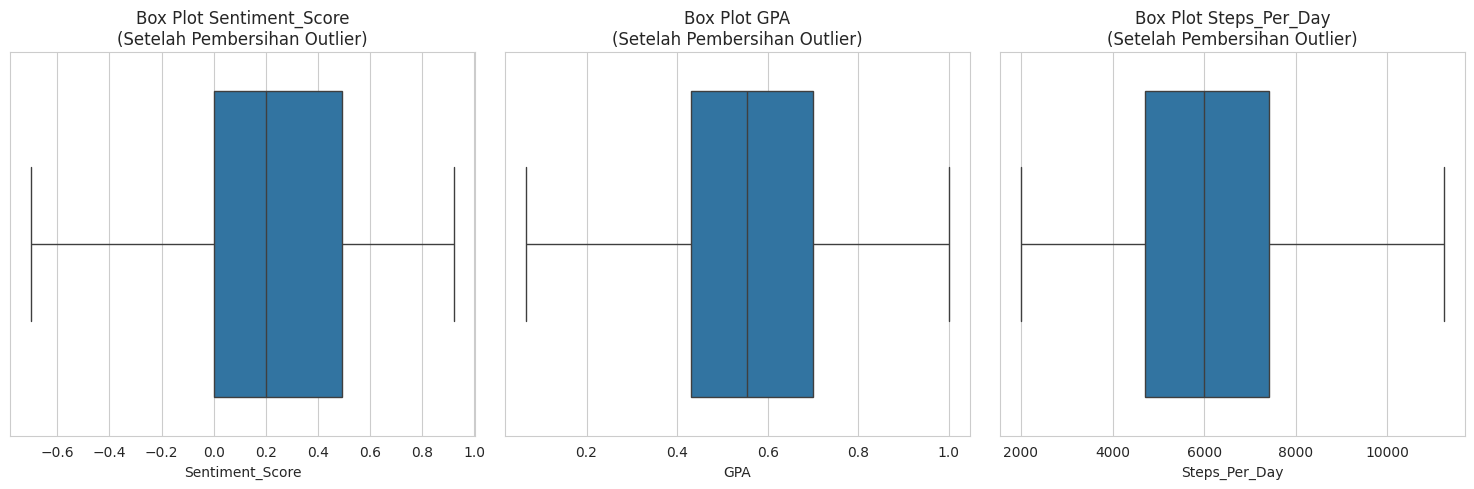

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variabel yang sudah dibersihkan
columns = ['Sentiment_Score', 'GPA', 'Steps_Per_Day']

plt.figure(figsize=(15, 5))
sns.set_style("whitegrid")

for i, col in enumerate(columns):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x=df_clean[col])
    plt.title(f'Box Plot {col}\n(Setelah Pembersihan Outlier)')

plt.tight_layout()
plt.show()

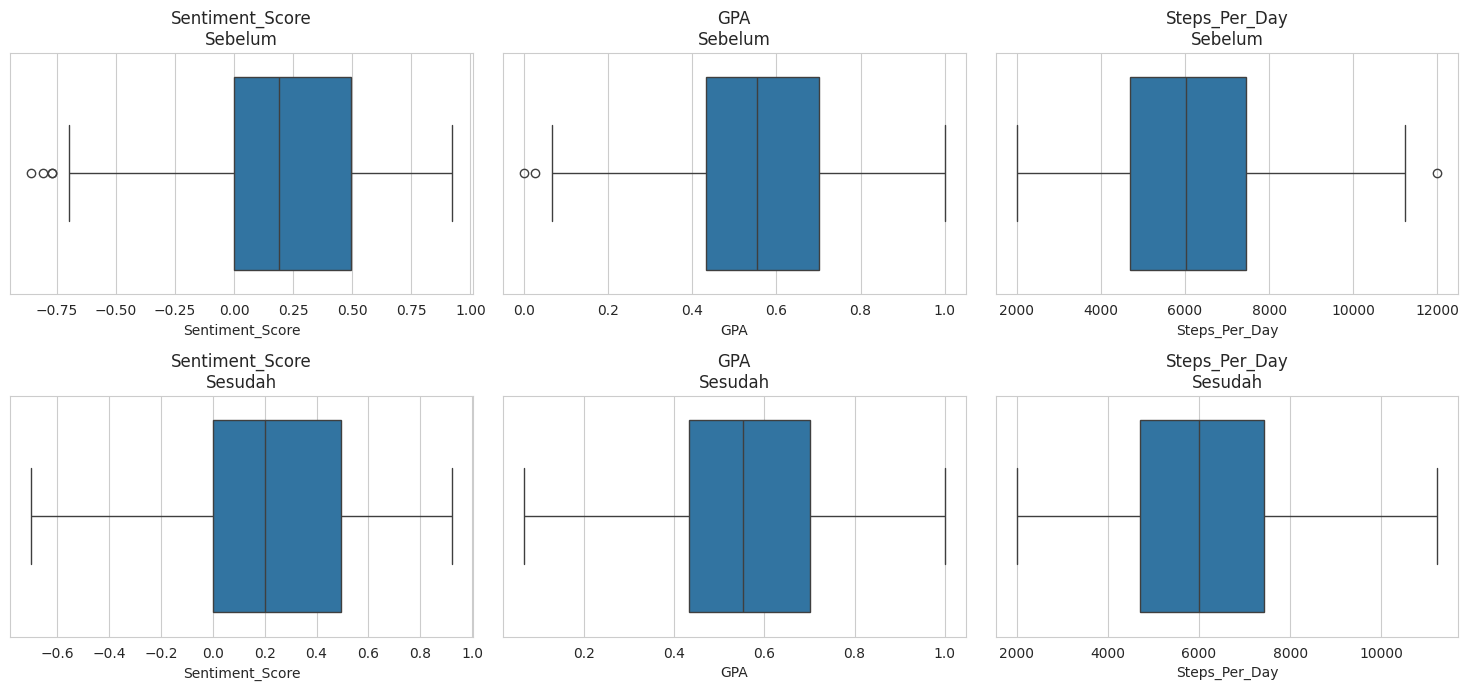

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

columns = ['Sentiment_Score', 'GPA', 'Steps_Per_Day']

plt.figure(figsize=(15, 10))

for i, col in enumerate(columns):

    # Sebelum
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'{col}\nSebelum')

    # Sesudah
    plt.subplot(3, 3, i + 4)
    sns.boxplot(x=df_clean[col])
    plt.title(f'{col}\nSesudah')

plt.tight_layout()
plt.show()

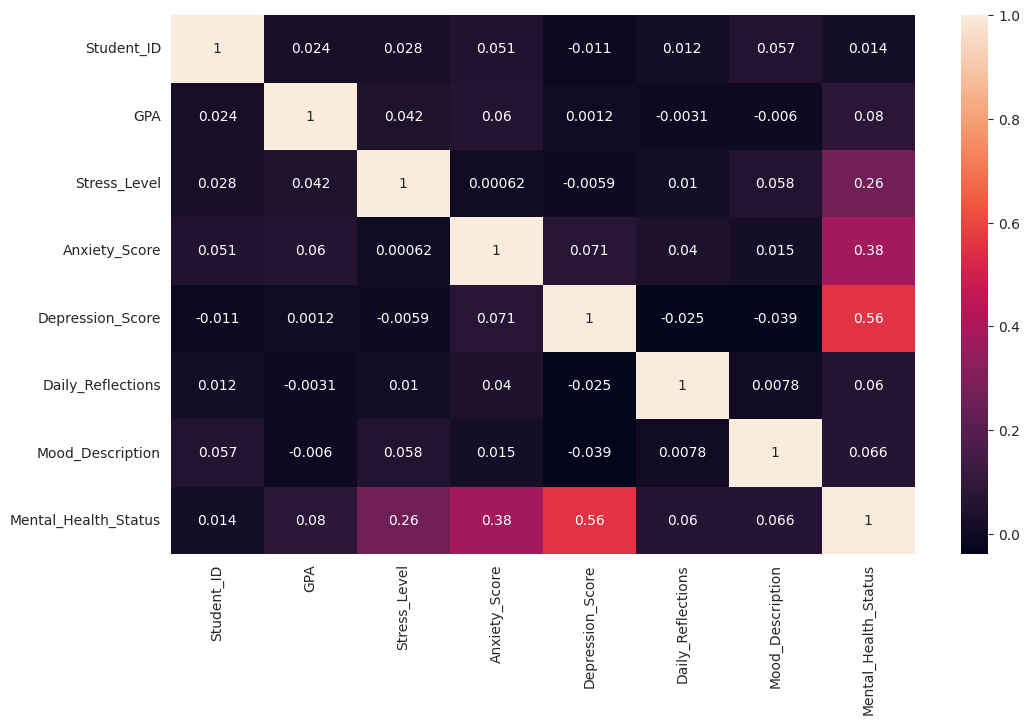

In [41]:
#konsturuksi Data

# hitung korelasi
corrmat = df.corr()

# tampilkan heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(corrmat, annot=True)
plt.show()

# cara membaca hitmap semakin terang

In [54]:
 df = df.drop(columns=[
     'Age',
     'Gender',
     'Sleep_Hours',
     'Steps_Per_Day',
     'Sentiment_Score'
 ])

In [52]:
df_clean.to_csv('mental_health_dataset_clean.csv', index=False)

In [51]:
print(df.head(5))

        GPA  Stress_Level  Anxiety_Score  Depression_Score  Daily_Reflections  \
0  0.453875          1.00       0.952381          0.222222                280   
1  0.535055          1.00       0.142857          0.259259                293   
2  0.826568          1.00       0.523810          0.888889                328   
3  0.276753          0.75       0.714286          0.518519                  0   
4  0.583026          0.00       0.095238          0.148148                206   

   Mood_Description  Mental_Health_Status  
0                 1                     2  
1                 6                     2  
2                 4                     2  
3                 4                     2  
4                 1                     0  


In [55]:
fitur = df.iloc[:,0:6] #Mengambil semua kolom kecuali yang terakhir sebagai fitur
target = df.iloc[:,6] #Mengambil kolom terakhir sebagai target
fitur

,GPA,Stress_Level,Anxiety_Score,Depression_Score,Daily_Reflections,Mood_Description
0,0.453875,1.00,0.952381,0.222222,280,1
1,0.535055,1.00,0.142857,0.259259,293,6
2,0.826568,1.00,0.523810,0.888889,328,4
3,0.276753,0.75,0.714286,0.518519,0,4
4,0.583026,0.00,0.095238,0.148148,206,1
...,...,...,...,...,...,...
495,0.756458,0.75,0.000000,0.777778,208,2
496,0.712177,0.25,0.333333,0.111111,12,0
497,0.579336,0.75,0.809524,0.037037,312,2
498,0.428044,0.75,0.666667,0.000000,72,5


In [56]:
target

,Mental_Health_Status
0,2
1,2
2,2
3,2
4,0
...,...
495,2
496,0
497,2
498,1


In [57]:
from sklearn.model_selection import train_test_split #untuk membagi data set menjadi data latih dan uji

x_latih, x_uji, y_latih, y_uji = train_test_split(fitur, target, test_size=0.3)
#test_size=0.3 artiny 30 % data set jadi data uji sisa nya jadi data latih

In [58]:
x_latih

,GPA,Stress_Level,Anxiety_Score,Depression_Score,Daily_Reflections,Mood_Description
241,0.527675,0.75,0.428571,0.222222,23,1
61,0.542435,0.25,0.190476,0.296296,233,2
209,0.638376,1.00,0.380952,0.962963,91,2
197,0.822878,0.00,0.523810,0.703704,209,2
448,0.409594,0.00,0.761905,0.777778,259,0
...,...,...,...,...,...,...
299,0.557196,1.00,0.142857,0.703704,381,5
152,0.774908,1.00,0.619048,0.037037,469,0
204,0.889299,0.25,0.666667,0.037037,430,5
64,0.450185,0.75,0.523810,0.296296,102,0


In [59]:
y_latih

,Mental_Health_Status
241,1
61,1
209,2
197,2
448,2
...,...
299,2
152,2
204,1
64,1


In [60]:
x_uji

,GPA,Stress_Level,Anxiety_Score,Depression_Score,Daily_Reflections,Mood_Description
481,0.590406,0.75,0.523810,0.666667,340,4
471,0.557196,0.50,0.809524,0.555556,295,6
149,0.771218,0.25,0.952381,0.333333,317,1
238,0.523985,0.25,0.619048,0.111111,251,0
286,0.516605,0.00,0.809524,0.333333,412,1
...,...,...,...,...,...,...
21,0.405904,0.00,0.904762,0.592593,196,4
171,0.435424,0.75,0.142857,0.962963,189,3
260,0.428044,0.50,0.380952,0.000000,421,4
427,0.701107,0.75,0.666667,0.666667,49,6


In [61]:
y_uji

,Mental_Health_Status
481,2
471,2
149,2
238,1
286,2
...,...
21,2
171,2
260,1
427,2


In [62]:
#normalisas
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_latih = scaler.fit_transform(x_latih)

X_uji = scaler.transform(x_uji)

In [63]:
#Model RandomForest Classifier
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(
    x_latih,
    y_latih
)
y_pred = model.predict(x_uji)

In [65]:
#Mode2
from sklearn import tree

In [66]:
from sklearn import tree
clf = tree.DecisionTreeClassifier() #fungsi decision tree adalah algoritam clasifikasi
clf = clf.fit(x_latih, y_latih) #latih dengan data latih + label latih, fitting =training
y_pred1 = clf.predict(x_uji)

In [67]:
y_pred

array([2, 2, 2, 1, 2, 1, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 1,
       1, 2, 1, 2, 2, 2, 2, 1, 1, 2, 2, 2, 0, 2, 2, 2, 1, 1, 2, 2, 2, 2,
       1, 2, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 1, 2, 2, 2, 1, 2, 2, 2, 2, 2,
       2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 1, 1, 1, 1, 2, 1, 2,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 1, 2, 1, 2, 2, 2, 2, 2, 0,
       2, 1, 2, 1, 2, 2, 1, 2, 1, 2, 2, 1, 2, 2, 2, 2, 1, 1, 1, 2, 2, 1,
       1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 1, 2, 2, 1, 2, 2])

In [68]:
y_pred1

array([2, 2, 2, 1, 2, 0, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 1,
       1, 2, 1, 2, 2, 2, 2, 1, 1, 2, 2, 2, 0, 2, 2, 2, 1, 1, 2, 2, 2, 2,
       1, 2, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 1, 2, 2, 2, 1, 2, 2, 2, 2, 2,
       2, 1, 0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 1, 1, 1, 1, 2, 1, 2,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 1, 2, 1, 2, 2, 2, 2, 2, 0,
       2, 1, 2, 1, 2, 2, 1, 2, 1, 2, 2, 1, 2, 2, 2, 2, 1, 1, 1, 2, 2, 1,
       1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 1, 2, 2, 1, 2, 2])

In [69]:
y_uji

,Mental_Health_Status
481,2
471,2
149,2
238,1
286,2
...,...
21,2
171,2
260,1
427,2


In [70]:
#Clasifikasi
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report #sintax data perbandingan data uji dan hasl prediksi
print("RandomForest Classifier")
akurasi = accuracy_score(y_uji, y_pred)
print("Akurasi:", akurasi)

print("\nConfusion Matrix:")
print(confusion_matrix(y_uji, y_pred))

# Laporan klasifikasi (precision, recall, f1-score)
print("\nClassification Report:")
print(classification_report(y_uji, y_pred))

#Clasifikasi
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report #sintax data perbandingan data uji dan hasl prediksi
print("DecisionTreeClassifier")
akurasi = accuracy_score(y_uji, y_pred1)
print("Akurasi:", akurasi)

print("\nConfusion Matrix:")
print(confusion_matrix(y_uji, y_pred1))

# Laporan klasifikasi (precision, recall, f1-score)
print("\nClassification Report:")
print(classification_report(y_uji, y_pred1))

RandomForest Classifier
Akurasi: 0.98

Confusion Matrix:
[[  2   3   0]
 [  0  45   0]
 [  0   0 100]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.40      0.57         5
           1       0.94      1.00      0.97        45
           2       1.00      1.00      1.00       100

    accuracy                           0.98       150
   macro avg       0.98      0.80      0.85       150
weighted avg       0.98      0.98      0.98       150

DecisionTreeClassifier
Akurasi: 0.9933333333333333

Confusion Matrix:
[[  4   1   0]
 [  0  45   0]
 [  0   0 100]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.80      0.89         5
           1       0.98      1.00      0.99        45
           2       1.00      1.00      1.00       100

    accuracy                           0.99       150
   macro avg       0.99      0.93      0.96       150
weighted avg       0.99   

In [71]:
import joblib

joblib.dump(clf, 'mental_health_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model dan scaler berhasil disimpan")

Model dan scaler berhasil disimpan


In [72]:
!pip install streamlit
import streamlit as st
import joblib
import numpy as np

model = joblib.load(
    'mental_health_model.pkl'
)

scaler = joblib.load(
    'scaler.pkl'
)

st.title("Prediksi Kesehatan Mental Mahasiswa")

gpa = st.number_input(
    "GPA",
    0,
    100
)

stress = st.slider(
    "Stress Level",
    1,
    10
)

anxiety = st.slider(
    "Anxiety Score",
    1,
    10
)

depression = st.slider(
    "Depression Score",
    1,
    10
)

mood = st.number_input(
    "Mood_Description",
    0,
    6
)


if st.button("Prediksi"):

    data = np.array([[
        gpa,
        stress,
        anxiety,
        depression,
        1,
        mood,
       1,
        0.5
    ]])

    data = scaler.transform(data)

    hasil = model.predict(data)

    st.success(
        f"Status Mental Health: {hasil[0]}"
    )

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 73.0 MB/s eta 0:00:00


2026-06-09 23:48:25.419 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 23:48:25.642 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-09 23:48:25.642 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 23:48:25.644 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 23:48:25.646 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 23:48:25.647 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 23:48:25.648 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 23:48:25.649 Thread 'MainThread': mi

In [73]:
# app.py

import streamlit as st
import pandas as pd

# Judul aplikasi
st.title("Analisis Kesehatan Mental Mahasiswa")

# Upload dataset
uploaded_file = st.file_uploader("Upload Dataset CSV", type=["csv"])

if uploaded_file is not None:
    # Membaca dataset
    df = pd.read_csv(uploaded_file)

    st.subheader("Dataset Awal")
    st.dataframe(df.head())

    # Menghapus kolom yang tidak digunakan
    df = df.drop(columns=[
        'Age',
        'Gender',
        'Sleep_Hours',
        'Steps_Per_Day',
        'Sentiment_Score'
    ])

    st.subheader("Dataset Setelah Seleksi Fitur")
    st.dataframe(df.head())

    st.subheader("Informasi Dataset")
    st.write(df.shape)
    st.write(df.dtypes)

2026-06-09 23:48:35.869 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 23:48:35.870 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 23:48:35.871 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 23:48:35.874 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 23:48:35.875 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 23:48:35.876 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 23:48:35.879 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 23:48:35.880 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [74]:
!pip install streamlit pyngrok

In [75]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [76]:
#melihat dir
import os
os.listdir()

['.config',
 'drive',
 'mental_health_dataset_clean.csv',
 'scaler.pkl',
 'mental_health_model.pkl',
 'sample_data']

In [77]:
#untuk mengcreate program app.py
%%writefile app.py

import streamlit as st

st.title("Aplikasi Prediksi Kesehatan Mental")
st.write("Deploy dengan Streamlit dan Ngrok")

Writing app.py


In [ ]:
!streamlit run app.py &



2026-06-09 23:49:59.218 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.181.169.108:8501



In [ ]:
from pyngrok import ngrok

In [ ]:
#from pyngrok import ngrok

#ngrok.kill()

In [ ]:
    ngrok.set_auth_token("3EnABBY56a5lnLe1NgE2zvKUuIl_7Z5zrZECxQbfwb2sTfsha")


In [ ]:
import subprocess
import time
from pyngrok import ngrok

# Ensure any existing ngrok tunnels are closed before trying to open a new one
ngrok.kill()

print("Starting Streamlit app in the background...")
# Start Streamlit app, using the 'app.py' file created earlier
subprocess.Popen(["streamlit", "run", "app.py"], stdout=subprocess.PIPE, stderr=subprocess.PIPE)

# Give Streamlit a moment to start up
time.sleep(5)

print("Opening ngrok tunnel...")
# Create an ngrok tunnel to the default Streamlit port (8501)
public_url = ngrok.connect(8501)

print("--------------------------------------------------")
print(f"Klik tautan ini untuk membuka Streamlit Anda: {public_url}")
print("--------------------------------------------------")
print("Ingat: Streamlit dan ngrok berjalan di latar belakang. Jika Anda ingin menghentikannya, pertimbangkan untuk memulai ulang runtime.")

In [ ]:
public_url = ngrok.connect(8501)

print(public_url)